In [76]:
import sys
!{sys.executable} -m pip install pandas prophet matplotlib openpyxl xgboost scikit-learn holidays

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
import holidays as pyholidays
from dateutil.easter import easter
from datetime import date, timedelta

In [58]:
# Load both Excel files
file_2024 = '/Users/kevinkim/projects/sales_forecasting/sales_2024.xlsx'
file_2025 = '/Users/kevinkim/projects/sales_forecasting/sales_2025.xlsx'


# Read all sheets from both files
sheets_2024 = pd.read_excel(file_2024, sheet_name=None)
sheets_2025 = pd.read_excel(file_2025, sheet_name=None)

# Combine all sheets into one dataframe
df = pd.concat(list(sheets_2024.values()) + list(sheets_2025.values()))

# Reset index and sort by date
df = df.sort_values('Date').reset_index(drop=True)

print(df.head(20))
print(df.shape)

         Date        Total
0  2024-01-01  1432.665484
1  2024-01-02  2242.965484
2  2024-01-03  2438.645484
3  2024-01-04  1926.895484
4  2024-01-05  2126.815484
5  2024-01-06  3011.195484
6  2024-01-07  2877.445484
7  2024-01-08  1813.915484
8  2024-01-09  1424.705484
9  2024-01-10  1449.875484
10 2024-01-11  1511.645484
11 2024-01-12  2086.245484
12 2024-01-13  3379.845484
13 2024-01-14  2596.785484
14 2024-01-15  2120.665484
15 2024-01-16  1226.795484
16 2024-01-17  1100.745484
17 2024-01-18  1582.105484
18 2024-01-19  1974.945484
19 2024-01-20  3580.075484
(731, 2)


In [59]:
# Prophet requires columns to be named 'ds' and 'y'
df_prophet = df.rename(columns={'Date': 'ds', 'Total': 'y'})

print(df_prophet.head())

          ds            y
0 2024-01-01  1432.665484
1 2024-01-02  2242.965484
2 2024-01-03  2438.645484
3 2024-01-04  1926.895484
4 2024-01-05  2126.815484


In [60]:
# Build and train the model
model = Prophet()
model.fit(df_prophet)

19:55:02 - cmdstanpy - INFO - Chain [1] start processing
19:55:02 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
# Create future dates to forecast (90 days into the future)
future = model.make_future_dataframe(periods=90)

# Generate the forecast
forecast = model.predict(future)

# Show the key columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

            ds         yhat   yhat_lower   yhat_upper
811 2026-03-22  2567.621659  1984.655633  3183.439118
812 2026-03-23  1383.493963   774.142259  1977.432246
813 2026-03-24  1209.121637   554.350382  1813.815712
814 2026-03-25  1222.443572   654.128049  1812.532403
815 2026-03-26  1284.443219   684.065302  1898.658403
816 2026-03-27  1784.317557  1185.568591  2443.741068
817 2026-03-28  2825.257766  2249.723252  3476.207322
818 2026-03-29  2573.068783  1980.602738  3205.044592
819 2026-03-30  1390.823466   826.403510  2002.898071
820 2026-03-31  1217.273105   595.830126  1840.331152


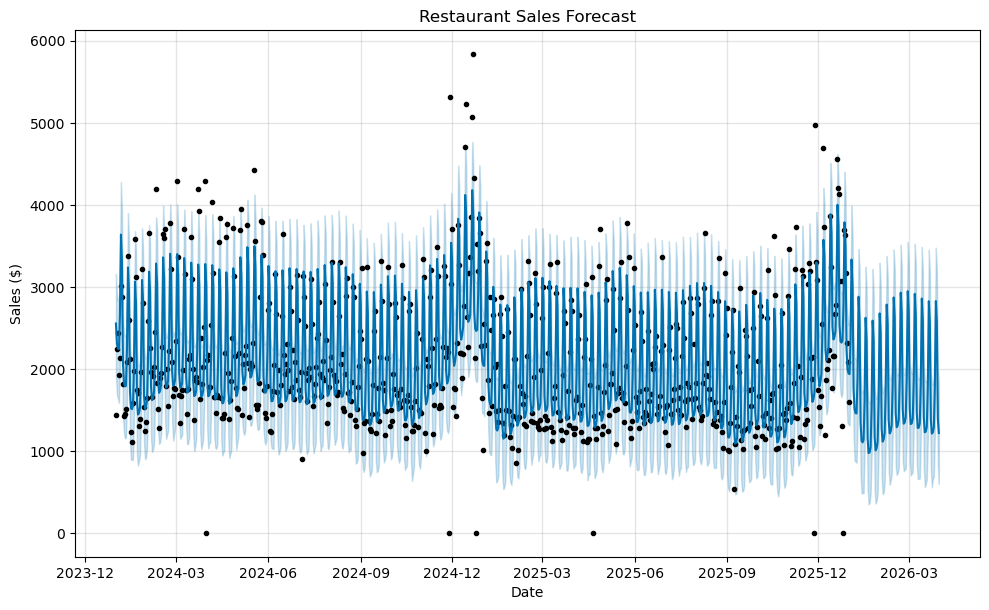

In [62]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title('Restaurant Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.show()

In [63]:
# Merge actual values with predicted values on the date column
merged = df_prophet.merge(forecast[['ds', 'yhat']], on='ds')

# Remove rows where actual sales is 0 or null (closed days)
merged = merged[merged['y'] > 0]

# Calculate MAPE
mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

print(f'MAPE: {mape:.2f}%')
print(f'Forecast Accuracy: {100 - mape:.2f}%')

MAPE: 14.87%
Forecast Accuracy: 85.13%


In [64]:
# Save the chart as a PNG
fig1.savefig('/Users/kevinkim/projects/sales_forecasting/sales_forecast_chart.png')

# Save the forecast data to Excel
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_excel(
    '/Users/kevinkim/projects/sales_forecasting/sales_forecast_output.xlsx', 
    index=False
)

print('Files saved successfully')

Files saved successfully


In [65]:
# Remove days where sales were 0 (closed days)
df_clean = df_prophet[df_prophet['y'] > 0]

print(f'Original rows: {len(df_prophet)}')
print(f'Cleaned rows: {len(df_clean)}')
print(f'Removed {len(df_prophet) - len(df_clean)} closed days')

Original rows: 731
Cleaned rows: 725
Removed 6 closed days


In [66]:
# Retrain model with cleaned data
model_clean = Prophet()
model_clean.fit(df_clean)

# Create future dates and forecast
future_clean = model_clean.make_future_dataframe(periods=90)
forecast_clean = model_clean.predict(future_clean)

# Calculate new MAPE
merged_clean = df_clean.merge(forecast_clean[['ds', 'yhat']], on='ds')
mape_clean = np.mean(np.abs((merged_clean['y'] - merged_clean['yhat']) / merged_clean['y'])) * 100

print(f'Original MAPE: 16.68%')
print(f'New MAPE: {mape_clean:.2f}%')
print(f'Original Accuracy: 83.32%')
print(f'New Accuracy: {100 - mape_clean:.2f}%')

19:55:03 - cmdstanpy - INFO - Chain [1] start processing
19:55:03 - cmdstanpy - INFO - Chain [1] done processing


Original MAPE: 16.68%
New MAPE: 15.05%
Original Accuracy: 83.32%
New Accuracy: 84.95%


In [67]:
# Retrain model with cleaned data and holidays
model_holidays = Prophet(holidays_prior_scale=10)
model_holidays.add_country_holidays(country_name='US')
model_holidays.fit(df_clean)

# Create future dates and forecast
future_holidays = model_holidays.make_future_dataframe(periods=90)
forecast_holidays = model_holidays.predict(future_holidays)

# Calculate new MAPE
merged_holidays = df_clean.merge(forecast_holidays[['ds', 'yhat']], on='ds')
mape_holidays = np.mean(np.abs((merged_holidays['y'] - merged_holidays['yhat']) / merged_holidays['y'])) * 100

print(f'Original MAPE: 16.68%')
print(f'New MAPE: {mape_holidays:.2f}%')
print(f'Original Accuracy: 83.32%')
print(f'New Accuracy: {100 - mape_holidays:.2f}%')

19:55:03 - cmdstanpy - INFO - Chain [1] start processing
19:55:03 - cmdstanpy - INFO - Chain [1] done processing


Original MAPE: 16.68%
New MAPE: 13.66%
Original Accuracy: 83.32%
New Accuracy: 86.34%


In [68]:
# Monthly totals for each year (Jan-Dec)
data_2022 = [52905.02, 51487.96, 59071.06, 59916.68, 65824.83, 67289.50, 66909.90, 67750.59, 66533.45, 65610.89, 71179.69, 103064.10]
data_2023 = [66254.49, 54499.82, 67015.53, 63403.94, 62487.52, 63051.16, 69553.24, 62800.94, 61773.05, 53948.85, 69617.63, 96057.45]
data_2024 = [63276.72, 67753.85, 66011.92, 68460.17, 69053.45, 65555.11, 60503.32, 61745.04, 58784.01, 56316.33, 68823.44, 91383.15]
data_2025 = [62182.78, 51694.70, 59811.42, 51935.57, 64538.57, 56067.66, 57920.04, 62058.23, 54332.34, 52905.02, 66682.14, 78953.50]

# Calculate monthly averages across all 4 years
monthly_avg = [(a+b+c+d)/4 for a,b,c,d in zip(data_2022, data_2023, data_2024, data_2025)]

# Calculate overall average
overall_avg = np.mean(monthly_avg)

# Calculate seasonal factors
seasonal_factors = [m/overall_avg for m in monthly_avg]

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for month, factor in zip(months, seasonal_factors):
    print(f'{month}: {factor:.3f}')

Jan: 0.945
Feb: 0.871
Mar: 0.974
Apr: 0.942
May: 1.012
Jun: 0.974
Jul: 0.985
Aug: 0.983
Sep: 0.933
Oct: 0.884
Nov: 1.068
Dec: 1.428


In [69]:
# Add seasonal factors as a new column
seasonal_factors = [0.945, 0.871, 0.974, 0.942, 1.012, 0.974, 0.985, 0.983, 0.933, 0.884, 1.068, 1.428]

df_clean['seasonal_factor'] = df_clean['ds'].dt.month.map(
    lambda x: seasonal_factors[x-1]
)

print(df_clean.head(10))

          ds            y  seasonal_factor
0 2024-01-01  1432.665484            0.945
1 2024-01-02  2242.965484            0.945
2 2024-01-03  2438.645484            0.945
3 2024-01-04  1926.895484            0.945
4 2024-01-05  2126.815484            0.945
5 2024-01-06  3011.195484            0.945
6 2024-01-07  2877.445484            0.945
7 2024-01-08  1813.915484            0.945
8 2024-01-09  1424.705484            0.945
9 2024-01-10  1449.875484            0.945


/var/folders/h0/_1b5f8v5625c14tshm3876lm0000gn/T/ipykernel_40343/63267589.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['seasonal_factor'] = df_clean['ds'].dt.month.map(


In [70]:
# Retrain model with holidays and seasonal factors
model_seasonal = Prophet(holidays_prior_scale=10)
model_seasonal.add_country_holidays(country_name='US')
model_seasonal.add_regressor('seasonal_factor')
model_seasonal.fit(df_clean)

# Create future dates
future_seasonal = model_seasonal.make_future_dataframe(periods=90)

# Add seasonal factors to future dates too
future_seasonal['seasonal_factor'] = future_seasonal['ds'].dt.month.map(
    lambda x: seasonal_factors[x-1]
)

# Generate forecast
forecast_seasonal = model_seasonal.predict(future_seasonal)

# Calculate MAPE
merged_seasonal = df_clean.merge(forecast_seasonal[['ds', 'yhat']], on='ds')
mape_seasonal = np.mean(np.abs((merged_seasonal['y'] - merged_seasonal['yhat']) / merged_seasonal['y'])) * 100

print(f'Original MAPE: 16.68%')
print(f'Holidays MAPE: 13.68%')
print(f'New MAPE: {mape_seasonal:.2f}%')
print(f'Original Accuracy: 83.32%')
print(f'Holidays Accuracy: 86.32%')
print(f'New Accuracy: {100 - mape_seasonal:.2f}%')

19:55:04 - cmdstanpy - INFO - Chain [1] start processing
19:55:04 - cmdstanpy - INFO - Chain [1] done processing


Original MAPE: 16.68%
Holidays MAPE: 13.68%
New MAPE: 13.63%
Original Accuracy: 83.32%
Holidays Accuracy: 86.32%
New Accuracy: 86.37%


In [71]:
# Start from clean data
df_xgb = df_clean.copy()

# Create features from date
df_xgb['day_of_week'] = df_xgb['ds'].dt.dayofweek
df_xgb['month'] = df_xgb['ds'].dt.month
df_xgb['day_of_month'] = df_xgb['ds'].dt.day
df_xgb['week_of_year'] = df_xgb['ds'].dt.isocalendar().week.astype(int)
df_xgb['is_weekend'] = (df_xgb['day_of_week'] >= 5).astype(int)
df_xgb['seasonal_factor'] = df_xgb['ds'].dt.month.map(
    lambda x: seasonal_factors[x-1]
)

print(df_xgb.head())
print(df_xgb.shape)

          ds            y  seasonal_factor  day_of_week  month  day_of_month  \
0 2024-01-01  1432.665484            0.945            0      1             1   
1 2024-01-02  2242.965484            0.945            1      1             2   
2 2024-01-03  2438.645484            0.945            2      1             3   
3 2024-01-04  1926.895484            0.945            3      1             4   
4 2024-01-05  2126.815484            0.945            4      1             5   

   week_of_year  is_weekend  
0             1           0  
1             1           0  
2             1           0  
3             1           0  
4             1           0  
(725, 8)


In [72]:
# Define features and target
features = ['day_of_week', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'seasonal_factor']
target = 'y'

# Split into train and test (use last 90 days as test)
train = df_xgb.iloc[:-90]
test = df_xgb.iloc[-90:]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f'Training rows: {len(train)}')
print(f'Testing rows: {len(test)}')

Training rows: 635
Testing rows: 90


In [73]:
# Train XGBoost model
model_xgb = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
model_xgb.fit(X_train, y_train)

# Make predictions on test set
y_pred = model_xgb.predict(X_test)

# Calculate MAPE
mape_xgb = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'Prophet MAPE: 13.68%')
print(f'XGBoost MAPE: {mape_xgb:.2f}%')
print(f'Prophet Accuracy: 86.32%')
print(f'XGBoost Accuracy: {100 - mape_xgb:.2f}%')

Prophet MAPE: 13.68%
XGBoost MAPE: 19.55%
Prophet Accuracy: 86.32%
XGBoost Accuracy: 80.45%


In [ ]:
# Get US holidays for 2024, 2025, 2026
us_holidays = pyholidays.US(years=[2024, 2025, 2026])

# Find specific holiday dates dynamically
def get_holiday_dates(holiday_name, years):
    return [date for date, name in us_holidays.items() if holiday_name in name and date.year in years]

years = [2024, 2025, 2026]

# Closed days
easter_dates = get_holiday_dates('Easter', years)
thanksgiving_dates = get_holiday_dates('Thanksgiving', years)
christmas_dates = get_holiday_dates('Christmas', years)

# Slow days
july4_dates = get_holiday_dates('Independence', years)
new_years_dates = get_holiday_dates('New Year', years)

print('Easter:', easter_dates)
print('Thanksgiving:', thanksgiving_dates)
print('Christmas:', christmas_dates)
print('July 4th:', july4_dates)
print('New Years:', new_years_dates)

Easter: []
Thanksgiving: [datetime.date(2024, 11, 28), datetime.date(2025, 11, 27), datetime.date(2026, 11, 26)]
Christmas: [datetime.date(2024, 12, 25), datetime.date(2025, 12, 25), datetime.date(2026, 12, 25)]
July 4th: [datetime.date(2024, 6, 19), datetime.date(2024, 7, 4), datetime.date(2025, 6, 19), datetime.date(2025, 7, 4), datetime.date(2026, 6, 19), datetime.date(2026, 7, 4), datetime.date(2026, 7, 3)]
New Years: [datetime.date(2024, 1, 1), datetime.date(2025, 1, 1), datetime.date(2026, 1, 1)]


In [80]:
# Easter - calculate manually
easter_dates = [easter(year) for year in years]

# Black Friday - day after Thanksgiving
black_friday_dates = [date + timedelta(days=1) for date in thanksgiving_dates]

# Christmas Eve
christmas_eve_dates = [date(year, 12, 24) for year in years]

# New Years Eve
new_years_eve_dates = [date(year, 12, 31) for year in years]

# July 4th only - filter out Juneteenth
july4_dates = [date(year, 7, 4) for year in years]

# Saturday before Christmas
sat_before_christmas_dates = []
for year in years:
    christmas = date(year, 12, 25)
    days_to_saturday = (christmas.weekday() - 5) % 7
    sat_before_christmas_dates.append(christmas - timedelta(days=days_to_saturday))

print('Easter:', easter_dates)
print('Black Friday:', black_friday_dates)
print('Christmas Eve:', christmas_eve_dates)
print('New Years Eve:', new_years_eve_dates)
print('July 4th:', july4_dates)
print('Saturday before Christmas:', sat_before_christmas_dates)

Easter: [datetime.date(2024, 3, 31), datetime.date(2025, 4, 20), datetime.date(2026, 4, 5)]
Black Friday: [datetime.date(2024, 11, 29), datetime.date(2025, 11, 28), datetime.date(2026, 11, 27)]
Christmas Eve: [datetime.date(2024, 12, 24), datetime.date(2025, 12, 24), datetime.date(2026, 12, 24)]
New Years Eve: [datetime.date(2024, 12, 31), datetime.date(2025, 12, 31), datetime.date(2026, 12, 31)]
July 4th: [datetime.date(2024, 7, 4), datetime.date(2025, 7, 4), datetime.date(2026, 7, 4)]
Saturday before Christmas: [datetime.date(2024, 12, 21), datetime.date(2025, 12, 20), datetime.date(2026, 12, 19)]


In [81]:
# Build custom holidays dataframe
custom_holidays = pd.DataFrame([
    # Closed days - high prior scale
    *[{'holiday': 'Easter', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 15} for d in easter_dates],
    *[{'holiday': 'Thanksgiving', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 15} for d in thanksgiving_dates],
    *[{'holiday': 'Christmas', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 15} for d in christmas_dates],
    
    # Slow days - moderate prior scale
    *[{'holiday': 'Christmas_Eve', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 10} for d in christmas_eve_dates],
    *[{'holiday': 'New_Years_Eve', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 10} for d in new_years_eve_dates],
    *[{'holiday': 'New_Years_Day', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 10} for d in new_years_dates],
    *[{'holiday': 'Fourth_of_July', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 10} for d in july4_dates],
    
    # Busy days - high prior scale
    *[{'holiday': 'Black_Friday', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 15} for d in black_friday_dates],
    *[{'holiday': 'Saturday_Before_Christmas', 'ds': d, 'lower_window': 0, 'upper_window': 0, 'prior_scale': 15} for d in sat_before_christmas_dates],
])

print(custom_holidays)

                      holiday          ds  lower_window  upper_window  \
0                      Easter  2024-03-31             0             0   
1                      Easter  2025-04-20             0             0   
2                      Easter  2026-04-05             0             0   
3                Thanksgiving  2024-11-28             0             0   
4                Thanksgiving  2025-11-27             0             0   
5                Thanksgiving  2026-11-26             0             0   
6                   Christmas  2024-12-25             0             0   
7                   Christmas  2025-12-25             0             0   
8                   Christmas  2026-12-25             0             0   
9               Christmas_Eve  2024-12-24             0             0   
10              Christmas_Eve  2025-12-24             0             0   
11              Christmas_Eve  2026-12-24             0             0   
12              New_Years_Eve  2024-12-31          

In [82]:
# Add regressors to clean dataframe
df_final = df_clean.copy()

df_final['is_late_december'] = (
    (df_final['ds'].dt.month == 12) & 
    (df_final['ds'].dt.day >= 15)
).astype(int)

df_final['is_december_weekend'] = (
    (df_final['ds'].dt.month == 12) & 
    (df_final['ds'].dt.dayofweek >= 5)
).astype(int)

print(df_final[df_final['ds'].dt.month == 12][['ds', 'y', 'is_late_december', 'is_december_weekend']].head(20))

            ds         y  is_late_december  is_december_weekend
335 2024-12-01  3701.714                 0                    1
336 2024-12-02  1539.104                 0                    0
337 2024-12-03  1759.974                 0                    0
338 2024-12-04  1748.914                 0                    0
339 2024-12-05  1423.554                 0                    0
340 2024-12-06  2309.764                 0                    0
341 2024-12-07  3754.224                 0                    1
342 2024-12-08  3260.384                 0                    1
343 2024-12-09  2187.504                 0                    0
344 2024-12-10  2195.724                 0                    0
345 2024-12-11  1883.664                 0                    0
346 2024-12-12  2176.304                 0                    0
347 2024-12-13  2758.934                 0                    0
348 2024-12-14  4698.524                 0                    1
349 2024-12-15  5223.254                

In [83]:
# Train final model
model_final = Prophet(holidays=custom_holidays, holidays_prior_scale=10)
model_final.add_regressor('is_late_december')
model_final.add_regressor('is_december_weekend')
model_final.fit(df_final[['ds', 'y', 'is_late_december', 'is_december_weekend']])

# Create future dates
future_final = model_final.make_future_dataframe(periods=90)

# Add regressors to future dataframe
future_final['is_late_december'] = (
    (future_final['ds'].dt.month == 12) & 
    (future_final['ds'].dt.day >= 15)
).astype(int)

future_final['is_december_weekend'] = (
    (future_final['ds'].dt.month == 12) & 
    (future_final['ds'].dt.dayofweek >= 5)
).astype(int)

# Generate forecast
forecast_final = model_final.predict(future_final)

# Calculate MAPE
merged_final = df_final.merge(forecast_final[['ds', 'yhat']], on='ds')
merged_final = merged_final[merged_final['y'] > 0]
mape_final = np.mean(np.abs((merged_final['y'] - merged_final['yhat']) / merged_final['y'])) * 100

print(f'Original MAPE: 16.68%')
print(f'Holidays MAPE: 13.68%')
print(f'Final MAPE: {mape_final:.2f}%')
print(f'Original Accuracy: 83.32%')
print(f'Holidays Accuracy: 86.32%')
print(f'New Accuracy: {100 - mape_final:.2f}%')

20:27:10 - cmdstanpy - INFO - Chain [1] start processing
20:27:10 - cmdstanpy - INFO - Chain [1] done processing


Original MAPE: 16.68%
Holidays MAPE: 13.68%
Final MAPE: 13.88%
Original Accuracy: 83.32%
Holidays Accuracy: 86.32%
New Accuracy: 86.12%
